In [10]:
import pandas as pd # импортируйте библиотеку pandas
from sklearn.pipeline import Pipeline # импортируйте Pipeline и OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv')  # считайте файл ds_s18t2_customer_segmentation.csf

df = df.drop(columns=['id', 'date_first_purchase'], axis=1)   # удалите столбцы id и date_first_purchase
cat_cols = ['education', 'marital_status']    # создайте список категориальных признаков
num_cols = [x for x in df.columns if x not in cat_cols]  # создайте список числовых признаков

cat_pipeline = Pipeline(
    steps=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore'))
    ]
)  # создайте пайплайн для работы с категориальными признаками

print(cat_pipeline)

Pipeline(steps=[('one_hot', OneHotEncoder(handle_unknown='ignore'))])


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline(steps=[('scaler', StandardScaler())])

preprocess = ColumnTransformer(
	transformers=[
		('cat_pipeline', cat_pipeline, cat_cols), 
		('num_pipeline', num_pipeline, num_cols), 
	]
)


### Метод локтя

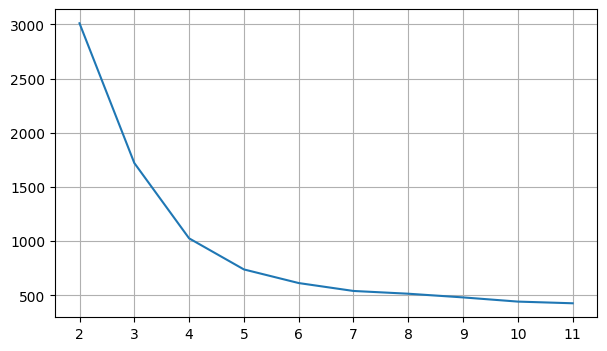

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ks = list(range(2, 12))
wcss = []

for k in ks:
	pipe = Pipeline(
		steps=[
			('preproc', preprocess),
			('model', KMeans(n_clusters=k, random_state=42))
        ]
    )
	pipe.fit(df)
	inertia = pipe['model'].inertia_       # извлеките значение WCSS из модели в пайплайне
	wcss.append(inertia)      # добавьте полученное значение к списку wcss

plt.figure(figsize=(7, 4))
plt.plot(list(ks), wcss)    # постройте график WCSS
plt.xticks(list(ks))  # добавьте количество кластеров по оси X
plt.grid()
plt.show()


In [17]:
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score  # импортируйте pairwise_distances и silhouette_score
import numpy as np

model = Pipeline(
    steps=[
        ('preproc', preprocess),
        ('model', KMeans(n_clusters=4, random_state=42))
    ]
).fit(df)  # создайте и обучите пайплайн модели KMeans с n_clusters=4

wcss = model['model'].inertia_  # получите значение WCSS из обученной модели

# посчитайте межкластерное расстояние
centers = model['model'].cluster_centers_  # получите центры кластеров из модели
d = pairwise_distances(centers, metric="euclidean")               # посчитайте попарную матрицу расстояний между кластерами
mask = ~np.eye(d.shape[0], dtype=bool)     # добавьте маску диагонали

inter_min = d[mask].min()   # посчитайте минимальное расстояние между кластерами
inter_mean = d[mask].mean()  # посчитайте среднее межкластерное расстояние

# посчитайте силуэтный коэффициент
X = preprocess.transform(df)         # преобразуйте датасет с помощью трансформера preprocess
labels = model['model'].labels_     #  получите метки кластеров из модели
sil_score = silhouette_score(X, labels=labels)  # посчитайте силуэтный коэффициент

print(f"WCSS: {wcss:.2f}")
print(f"Минимальное межкластерное расстояние: {inter_min:.2f}")
print(f"Среднее межкластерное расстояние: {inter_mean:.2f}")
print(f"Силуэтный коэффициент: {sil_score:.2f}")

WCSS: 1026.25
Минимальное межкластерное расстояние: 2.96
Среднее межкластерное расстояние: 4.20
Силуэтный коэффициент: 0.71


Анализ:
- Так как минимальное межкластерное расстояние (2,96) заметно меньше среднего (4,20), вероятно, существует пара кластеров, которые ближе друг к другу, чем остальные, и их стоит дополнительно проверить на слипание
- При силуэтном коэффициенте 0,71 можно ожидать, что большинство объектов имеют правильную принадлежность кластеру


## Кластеризация для feature engineering

Продуктовая задача:
- нужно заранее понимать, какой средний чек ожидать от клиента, чтобы персонализировать рекламу, оценивать LTV-стратегии и точнее таргетировать коммуникации.

Датасет:
- education — образование;
- marital_status — семейное положение;
- income — доход;
- kids — количество детей;
- num_purchases_at_shop — количество покупок в магазине;
- num_web_purchases — количество онлайн-заказов.

Таргет:
- Целевая переменная — avg_purchase_sum — средний чек.


Идея кластеризации здесь заключается в том, чтобы найти типажи клиентов по демографии и поведению. Поэтому логично взять в кластеризацию все те признаки, которые есть в датасете, кроме года рождения и даты первой покупки.

In [19]:
# Импорт библиотек
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

# Загрузка датасета
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv")

# Категориальные и числовые признаки отбираются в датасет X
cat_cols = ["education", "marital_status"]
num_cols = ["income", "kids", "num_purchases_at_shop", "num_web_purchases"]

X = df[cat_cols + num_cols]

# Целевая переменная avg_purchase_sum сохраняется в переменную y
y = df["avg_purchase_sum"] 

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 450
Размер тестовой выборки: 150


In [20]:
# Препроцессинг для KMeans
prep_for_kmeans = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Пайплайн KMeans
kmeans_pipe = Pipeline(
    steps=[
        ("prep", prep_for_kmeans),
        ("kmeans", KMeans(n_clusters=5, init="k-means++", random_state=42)),
    ]
)

# Обучение кластеризации на обучающей выборке
kmeans_pipe.fit(X_train)

# Для удобства вынесем обученную модель из пайплайна в отдельную переменную
kmeans = kmeans_pipe.named_steps["kmeans"]

print(kmeans)

KMeans(n_clusters=5, random_state=42)


In [21]:
# Перевод представления признаков X обучающей и тестовой выборки в пространство KMeans 
X_train_emb = kmeans_pipe.named_steps["prep"].transform(X_train)
X_test_emb = kmeans_pipe.named_steps["prep"].transform(X_test)

# Получаем метки кластеров
train_cluster = kmeans.predict(X_train_emb)
test_cluster = kmeans.predict(X_test_emb)

In [22]:
# Центры кластеров
train_centers = kmeans.cluster_centers_[train_cluster]
test_centers = kmeans.cluster_centers_[test_cluster]

# Расчёт расстояний от объектов до центров
train_dist_to_own = np.sqrt(((X_train_emb - train_centers) ** 2).sum(axis=1))
test_dist_to_own = np.sqrt(((X_test_emb - test_centers) ** 2).sum(axis=1))

print(f"Расстояния до собственного центра: \n{train_dist_to_own[:10]}\n")
print(f"Расстояния до чужих центров: \n{test_dist_to_own[:10]}")

Расстояния до собственного центра: 
[0.13951706 0.43031306 0.03237347 0.26457479 0.08463606 1.37401919
 0.2439292  0.3921904  0.20275751 0.3291327 ]

Расстояния до чужих центров: 
[0.04295198 0.32344419 0.20861402 0.36178179 0.35439221 0.02461745
 0.20567434 0.08221981 0.07563142 0.38923597]


In [23]:
# Расстояния от объекта до центра каждого кластера
train_dist = kmeans.transform(X_train_emb)
test_dist  = kmeans.transform(X_test_emb)

print(f"Расстояния до центров кластеров для первых 10 наблюдений обучающей выборки: \n\n{train_dist[:10]}")

Расстояния до центров кластеров для первых 10 наблюдений обучающей выборки: 

[[4.23664876 0.13951706 3.37018736 4.63520331 3.51998761]
 [3.99787075 0.43031306 3.28037769 4.54902734 3.51199915]
 [3.75883326 4.69451042 2.91580666 0.03237347 3.67395768]
 [4.34889294 0.26457479 3.51550729 4.84430074 3.6868302 ]
 [4.22317821 0.08463606 3.45882426 4.72824115 3.56257187]
 [1.37401919 4.83465977 3.02989368 4.31079778 3.04377573]
 [2.50861692 3.42540947 2.63965416 3.60936599 0.2439292 ]
 [2.43236986 3.64359797 2.61037862 3.41149986 0.3921904 ]
 [3.09063719 3.4664558  0.20275751 2.84134841 2.82259822]
 [4.47287698 0.3291327  3.58365835 4.90669939 3.71140272]]


In [24]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

train_cluster_ohe = ohe.fit_transform(train_cluster.reshape(-1, 1))
test_cluster_ohe  = ohe.transform(test_cluster.reshape(-1, 1))

print(f"OHE меток кластеров для первых 10 наблюдений обучающей выборки: \n\n{train_cluster_ohe[:10]}")

OHE меток кластеров для первых 10 наблюдений обучающей выборки: 

[[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [25]:
K = train_dist.shape[1]  # число кластеров

# DataFrame с кластерной меткой и расстоянием до своего центра
train_meta_df = pd.DataFrame(
    {
        "cluster_id": train_cluster,
        "dist_to_own_center": train_dist_to_own
    },
    index=X_train.index
)

test_meta_df = pd.DataFrame(
    {
        "cluster_id": test_cluster,
        "dist_to_own_center": test_dist_to_own
    },
    index=X_test.index
)

# DataFrame с расстояниями до центров
train_dist_df = pd.DataFrame(
    train_dist,
    index=X_train.index,
    columns=[f"dist_to_center_{i}" for i in range(K)]
)

test_dist_df = pd.DataFrame(
    test_dist,
    index=X_test.index,
    columns=[f"dist_to_center_{i}" for i in range(K)]
)

# DataFrame с OHE-метками кластеров
train_ohe_df = pd.DataFrame(
    train_cluster_ohe,
    index=X_train.index,
    columns=[f"cluster_{i}" for i in range(train_cluster_ohe.shape[1])]
)

test_ohe_df = pd.DataFrame(
    test_cluster_ohe,
    index=X_test.index,
    columns=[f"cluster_{i}" for i in range(test_cluster_ohe.shape[1])]
)

# объединение датафреймов
train_cluster_features = pd.concat([train_meta_df, train_dist_df, train_ohe_df], axis=1)
test_cluster_features  = pd.concat([test_meta_df,  test_dist_df,  test_ohe_df], axis=1)

# Создание расширенного датасета с дополнительными фичами от кластеризации
X_train_w_cluster = X_train.join(train_cluster_features)
X_test_w_cluster  = X_test.join(test_cluster_features)

# Вывод первых 5 строк обогащённой обучающей выборки
print(X_train_w_cluster.head())

      education marital_status    income  kids  num_purchases_at_shop  \
593         PhD       Divorced  125200.4     0                     13   
531         PhD       Divorced  133275.0     0                     11   
353  Graduation        Married   34162.7     0                      1   
332         PhD       Divorced  131875.3     0                     13   
534         PhD       Divorced  131915.7     0                     13   

     num_web_purchases  cluster_id  dist_to_own_center  dist_to_center_0  \
593                 12           1            0.139517          4.236649   
531                 12           1            0.430313          3.997871   
353                  1           3            0.032373          3.758833   
332                 13           1            0.264575          4.348893   
534                 12           1            0.084636          4.223178   

     dist_to_center_1  dist_to_center_2  dist_to_center_3  dist_to_center_4  \
593          0.139517    

In [26]:
from catboost import CatBoostRegressor
from sklearn.metrics import root_mean_squared_error

model = CatBoostRegressor(
    iterations=100,
    depth=3,
    learning_rate=0.1,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train, y_train,
    cat_features=cat_cols
)

y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"RMSE модели на базовых признаках: {rmse:.2f}")

RMSE модели на базовых признаках: 30.71


In [27]:
from catboost import CatBoostRegressor
from sklearn.metrics import root_mean_squared_error

model = CatBoostRegressor(
    iterations=100,
    depth=3,
    learning_rate=0.1,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train_w_cluster, y_train,
    cat_features=cat_cols
)

y_pred = model.predict(X_test_w_cluster)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"RMSE модели на расширенной выборке: {rmse:.2f}")

RMSE модели на расширенной выборке: 20.81


###  Интерпретация результата

При использовании дополнительных признаков значение RMSE заметно снижается. Это означает, что кластерные признаки дают модели дополнительную информацию и помогают точнее предсказывать целевую переменную. Обычно это происходит по нескольким причинам:

1. Кластер задаёт типаж клиента, связанный со средним чеком. У разных групп клиентов средние чеки различаются, поэтому добавление метки кластера даёт модели короткий и сильный сигнал о типе клиента и часто снижает ошибку.
2. Расстояния до центров кластеров добавляют «мягкую принадлежность», а не только жёсткую метку. Эти признаки показывают, к каким типажам объект ближе. Например, два клиента могут иметь схожие исходные признаки, но один будет ближе к сегменту с высоким средним чеком, а другой — к сегменту с низким. Через расстояния модель учитывает эту разницу и точнее аппроксимирует целевую переменную.
3. Расстояние до центра собственного кластера отражает типичность объекта для своей группы. Даже внутри одного кластера объекты могут находиться близко к центру или на его границе. Граничные объекты часто ведут себя менее стабильно: у них выше вариативность целевой переменной или они ближе к другому типу. Признак типичности помогает модели скорректировать прогноз внутри сегмента и снизить ошибку.

Добавление кластерных признаков — один из приёмов инженерии признаков: создания новых признаков, которые дают модели дополнительный уровень абстракции над данными.